<a href="https://colab.research.google.com/github/w4bo/AA2627-unibo-dcai/blob/main/slides/automl-flaml.ipynb" target="_parent"><img src="images/colab-badge.svg" alt="Open In Colab"/></a>

---
subtitle: "AutoML"
bibliography:
  - refs/refs.bib
---

## Learning Outcomes

By the end of this 3-hour lab, you should be able to:

- Explain AutoML as algorithm selection, hyperparameter optimization, and resource allocation.
- Connect FLAML's budget-aware search to the Hutter and Vanschoren AutoML tutorial.
- Run AutoML on real classification and regression datasets.
- Compare AutoML models against manual scikit-learn baselines.
- Study how budget and metric choices change selected models.
- Describe what AutoML automates and what still needs human judgment.

## AutoML as a System

The Hutter and Vanschoren tutorial frames AutoML as meta-level learning and optimization around a learning system.

In this lab, the learning system is a tabular ML pipeline and the meta-level optimizer decides how to configure it.

## AutoML: Moving Parts

| Part | Meaning in this lab |
| --- | --- |
| Task | Dataset, target, and evaluation goal |
| Learning system | A candidate tabular ML pipeline |
| Optimizer | Algorithm selection and hyperparameter search |
| Budget | The time allowed for candidate evaluations |

FLAML gives us a compact way to run this process under an explicit time budget.

## Three-Hour Plan

| Time | Activity |
| --- | --- |
| 0:00-0:20 | Reading warm-up from `hutter-vanschoren-part1-2.pdf` |
| 0:20-0:55 | Real classification task: Adult Census Income |
| 0:55-1:30 | FLAML for classification and metric choice |
| 1:30-1:40 | Break |
| 1:40-2:15 | Real regression task: California Housing |
| 2:15-2:45 | Budget comparison and model inspection |
| 2:45-3:00 | Deliverables and wrap-up discussion |

## Reading Warm-Up

Open `slides/resources/hutter-vanschoren-part1-2.pdf` and skim the first two parts of the tutorial.

Focus on how AutoML turns model-building decisions into an optimization problem.

## Reading Checkpoints

Look for four ideas while reading:

- algorithm choice as a top-level hyperparameter;
- expensive black-box evaluations;
- random search as a strong baseline;
- multi-fidelity methods for saving time.

**Discussion question:** if AutoML returns a high-scoring model, what evidence do you still need before trusting it?

## AutoML as HPO

The algorithm choice can be treated as a top-level hyperparameter. Once the algorithm is chosen, many other hyperparameters become conditional.

## Conditional Choices

| If the optimizer chooses... | It may tune... |
| --- | --- |
| `random_forest` | tree depth, number of trees, leaf size |
| `logistic_regression` | regularization type and strength |
| `gradient_boosting` | learning rate, estimators, tree constraints |

This is why AutoML search spaces are structured rather than simple rectangular grids.

## Why Budgets Matter

A single evaluation means training and validating a candidate model. On real data, that can be slow.

FLAML is designed for economical AutoML: it tries to find good models under explicit resource constraints.

## Budgeted Search Loop

| Step | What happens |
| --- | --- |
| 1 | Propose a candidate learner and configuration |
| 2 | Train it on the training data |
| 3 | Validate it with the chosen metric |
| 4 | Use the result to choose the next candidate |
| 5 | Stop when the time budget is exhausted |

## 1. Setup

If you run this lab in Google Colab or a minimal Python environment, run the following cell first.

The setup cell installs only missing packages. The primary datasets are real public datasets; if network access is unavailable, the notebook falls back to real built-in scikit-learn datasets so the lab remains runnable.

In [ ]:
#| echo: false
# Install only packages missing from the current runtime.
import importlib.util
import subprocess
import sys

required_packages = ["flaml", "matplotlib", "numpy", "pandas", "sklearn"]
missing_packages = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]

if missing_packages:
    pip_names = []
    for pkg in missing_packages:
        if pkg == "sklearn":
            pip_names.append("scikit-learn")
        elif pkg == "flaml":
            pip_names.append("flaml[automl]")
        else:
            pip_names.append(pkg)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--break-system-packages", *pip_names])

time_budget=5

In [45]:
#| echo: false
# Import data, modeling, preprocessing, evaluation, and plotting tools.
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from flaml import AutoML
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_california_housing, fetch_openml, load_diabetes
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")

In [46]:
#| echo: false
# Keep OneHotEncoder compatible with recent and older scikit-learn versions.
from sklearn.metrics import root_mean_squared_error


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def evaluate_classifier(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    else:
        y_score = y_pred
    return {
        "accuracy": accuracy_score(y_eval, y_pred),
        "roc_auc": roc_auc_score(y_eval, y_score),
        "f1": f1_score(y_eval, y_pred),
    }


def evaluate_regressor(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    return {
        "rmse": root_mean_squared_error(y_eval, y_pred),
        "mae": mean_absolute_error(y_eval, y_pred),
        "r2": r2_score(y_eval, y_pred),
    }


def display_scores(label, scores):
    print(label)
    for name, value in scores.items():
        print(f"  {name:8s}: {value:.3f}")

## 2. Classification Dataset

The first real dataset is Adult Census Income from the UCI repository, loaded through OpenML.

The task is to predict whether a person earns more than 50K USD per year from demographic and work-related attributes.

## Why This Dataset Works

Adult Income is a useful AutoML teaching case because it includes:

- mixed numerical and categorical variables;
- missing values;
- class imbalance;
- a socially sensitive target.

Those properties make model selection more realistic than a tiny built-in dataset.

In [47]:
def load_adult_income(n_rows=8000):
    try:
        adult = fetch_openml("adult", version=2, as_frame=True)
        df = adult.frame.copy()
        df.columns = [c.strip().lower().replace("-", "_") for c in df.columns]
        if "class" in df.columns:
            df = df.rename(columns={"class": "income"})
        df = df.replace("?", np.nan).dropna()
        df["income"] = df["income"].astype(str).str.replace(".", "", regex=False).str.strip()
        df = df.sample(n=min(n_rows, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
        return df, "OpenML Adult Census Income"
    except Exception as exc:
        from sklearn.datasets import load_breast_cancer

        print(f"Could not download Adult from OpenML: {exc}")
        print("Falling back to the real built-in breast cancer dataset.")
        cancer = load_breast_cancer(as_frame=True)
        df = cancer.data.copy()
        df["income"] = cancer.target
        return df, "scikit-learn breast cancer fallback"


adult_df, adult_source = load_adult_income()
print(adult_source)
display(adult_df.head())
display(adult_df["income"].value_counts(normalize=True).rename("target_share").round(3))

OpenML Adult Census Income


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,19,Self-emp-not-inc,30800,10th,6,Married-spouse-absent,Adm-clerical,Unmarried,Amer-Indian-Eskimo,Female,0,0,40,United-States,<=50K
1,45,Private,26781,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
2,47,Private,431515,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K
3,23,Private,45713,Some-college,10,Never-married,Craft-repair,Other-relative,White,Male,0,0,40,United-States,<=50K
4,53,Local-gov,175897,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K


income
<=50K    0.756
>50K     0.244
Name: target_share, dtype: float64

In [48]:
classification_target = "income"
X_cls = adult_df.drop(columns=[classification_target])
y_raw = adult_df[classification_target]
y_cls = (y_raw == ">50K").astype(int)

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_cls,
)

numeric_cls = X_cls_train.select_dtypes(include=np.number).columns.tolist()
categorical_cls = [c for c in X_cls_train.columns if c not in numeric_cls]

def prepare_flaml_frame(X, categorical_columns=None, category_maps=None):
    X_flaml = X.copy()
    categorical_columns = [] if categorical_columns is None else list(categorical_columns)
    categorical_columns = [column for column in categorical_columns if column in X_flaml.columns]
    category_maps = {} if category_maps is None else category_maps

    for column in categorical_columns:
        values = X_flaml[column].astype(object).where(X_flaml[column].notna(), "__missing__")
        if column not in category_maps:
            category_maps[column] = {value: code for code, value in enumerate(pd.unique(values))}
        unknown_code = len(category_maps[column])
        X_flaml[column] = values.map(category_maps[column]).fillna(unknown_code).astype("int32")

    X_flaml.columns = pd.RangeIndex(X_flaml.shape[1])
    return X_flaml, category_maps

X_cls_train_flaml, cls_category_maps = prepare_flaml_frame(X_cls_train, categorical_cls)
X_cls_test_flaml, _ = prepare_flaml_frame(X_cls_test, categorical_cls, cls_category_maps)

print(f"Rows: {len(X_cls)}")
print(f"Features: {X_cls.shape[1]}")
print(f"Numerical features: {len(numeric_cls)}")
print(f"Categorical features: {len(categorical_cls)}")
print(f"Positive class share: {y_cls.mean():.3f}")

Rows: 8000
Features: 14
Numerical features: 6
Categorical features: 8
Positive class share: 0.244


## 3. Manual Classification Baseline

We build a baseline with explicit preprocessing:

- numeric features are scaled;
- categorical features are one-hot encoded;
- logistic regression predicts the income label.

This baseline is intentionally simple, but it is strong enough to make the AutoML comparison meaningful.

In [49]:
classification_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cls),
        ("cat", make_one_hot_encoder(), categorical_cls),
    ]
)

classification_baseline = Pipeline(
    steps=[
        ("preprocess", classification_preprocess),
        ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

classification_baseline.fit(X_cls_train, y_cls_train)
classification_baseline_scores = evaluate_classifier(classification_baseline, X_cls_test, y_cls_test)
display_scores("Manual classification baseline", classification_baseline_scores)
print("confusion matrix:")
print(confusion_matrix(y_cls_test, classification_baseline.predict(X_cls_test)))

Manual classification baseline
  accuracy: 0.847
  roc_auc : 0.898
  f1      : 0.656
confusion matrix:
[[1402  110]
 [ 196  292]]


## 4. FLAML for Classification

FLAML can work with pandas data directly, including mixed tabular inputs. We give it the same train/test split and reserve the test set for final evaluation.

The first AutoML run optimizes ROC AUC for 60 seconds.

In [50]:
X_cls_train

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
1231,55,Self-emp-not-inc,119762,10th,6,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,50,United-States
6385,30,Private,217296,Assoc-voc,11,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,35,United-States
7385,49,Private,191389,HS-grad,9,Divorced,Sales,Not-in-family,White,Female,0,0,40,United-States
4823,34,Local-gov,143766,Some-college,10,Never-married,Protective-serv,Own-child,White,Male,0,0,40,United-States
3917,47,Private,235108,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,5178,0,40,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1658,33,Local-gov,190290,Assoc-voc,11,Never-married,Protective-serv,Not-in-family,White,Male,0,0,56,United-States
1514,51,Self-emp-inc,54342,Prof-school,15,Divorced,Prof-specialty,Not-in-family,White,Male,27828,0,60,United-States
6133,56,Private,179127,10th,6,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,35,Italy
5700,49,Self-emp-not-inc,181717,Bachelors,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,7,United-States


In [51]:
classification_automl = AutoML()

classification_automl.fit(
    X_train=X_cls_train_flaml,
    y_train=y_cls_train,
    task="classification",
    metric="roc_auc",
    time_budget=time_budget,
    log_file_name="flaml_adult_roc_auc_60s.log",
    seed=RANDOM_STATE,
    verbose=1,
)

In [52]:
print(f"Best estimator: {classification_automl.best_estimator}")
print(f"Best validation loss: {classification_automl.best_loss:.6f}")
print(f"Training time for best config: {classification_automl.best_config_train_time:.3f}s")
classification_automl.best_config

Best estimator: xgboost
Best validation loss: 0.083772
Training time for best config: 0.235s


{'n_estimators': 292,
 'max_leaves': 5,
 'min_child_weight': np.float64(0.14832537496352421),
 'learning_rate': np.float64(0.07724084206236564),
 'subsample': np.float64(0.8485801679895006),
 'colsample_bylevel': np.float64(0.9286855614834028),
 'colsample_bytree': 1.0,
 'reg_alpha': np.float64(0.004074821343348109),
 'reg_lambda': np.float64(1.6155560963224975)}

In [53]:
classification_automl_scores = evaluate_classifier(classification_automl, X_cls_test_flaml, y_cls_test)
display_scores("FLAML classification model", classification_automl_scores)
print("confusion matrix:")
print(confusion_matrix(y_cls_test, classification_automl.predict(X_cls_test_flaml)))

pd.DataFrame(
    [classification_baseline_scores, classification_automl_scores],
    index=["manual_baseline", "flaml"],
).round(3)

FLAML classification model
  accuracy: 0.859
  roc_auc : 0.910
  f1      : 0.671
confusion matrix:
[[1428   84]
 [ 199  289]]


,accuracy,roc_auc,f1
manual_baseline,0.847,0.898,0.656
flaml,0.858,0.910,0.671


## Random Search Is a Real Baseline

The tutorial emphasizes that random search can outperform grid search when only a few hyperparameters really matter.

## Grid Search vs Random Search

| Search style | Behavior |
| --- | --- |
| Grid search | Spends trials evenly across all dimensions |
| Random search | Samples more distinct values for each important dimension |
| AutoML search | Adds model choice, budgets, and adaptive allocation |

AutoML systems should be compared against sensible baselines, not just exhaustive grid search.

## 5. Classification Metrics

On Adult Income, accuracy can look good even when the model performs poorly on the minority class.

Run the same AutoML procedure with different optimization metrics and compare the final test results.

In [54]:
def run_flaml_classification(metric="roc_auc", time_budget=time_budget):
    model = AutoML()
    started_at = time.time()
    model.fit(
        X_train=X_cls_train_flaml,
        y_train=y_cls_train,
        task="classification",
        metric=metric,
        time_budget=time_budget,
        log_file_name=f"flaml_adult_{metric}_{time_budget}s.log",
        seed=RANDOM_STATE,
        verbose=0,
    )
    elapsed = time.time() - started_at
    scores = evaluate_classifier(model, X_cls_test_flaml, y_cls_test)
    return {
        "metric": metric,
        "budget": time_budget,
        "elapsed": elapsed,
        "best_estimator": model.best_estimator,
        "best_loss": model.best_loss,
        **scores,
    }


classification_metric_results = pd.DataFrame(
    [run_flaml_classification(metric=m, time_budget=time_budget) for m in ["accuracy", "roc_auc", "f1"]]
)
classification_metric_results.round(3)

,metric,budget,elapsed,best_estimator,best_loss,accuracy,roc_auc,f1
0,accuracy,45,45.107,lgbm,0.133,0.858,0.910,0.664
1,roc_auc,45,45.329,xgboost,0.084,0.858,0.910,0.671
2,f1,45,45.687,xgboost,0.302,0.857,0.911,0.677


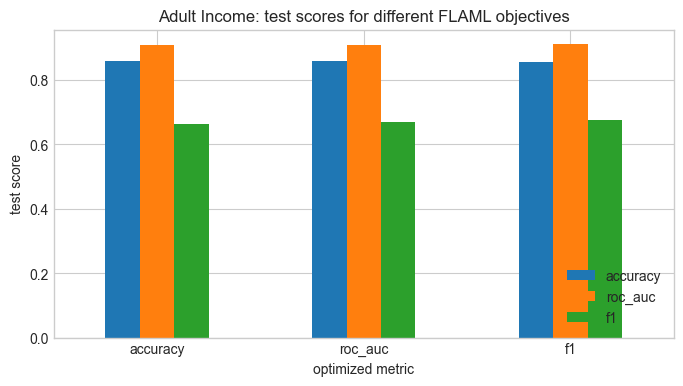

In [55]:
fig, ax = plt.subplots(figsize=(8, 4))
classification_metric_results.set_index("metric")[["accuracy", "roc_auc", "f1"]].plot(kind="bar", ax=ax)
ax.set_title("Adult Income: test scores for different FLAML objectives")
ax.set_xlabel("optimized metric")
ax.set_ylabel("test score")
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.show()

### Classification Questions

1. Which metric selected the strongest model for ROC AUC?
2. Which metric selected the strongest model for F1?
3. Which errors are more costly in this task?
4. What additional fairness or governance checks would you run before deployment?

## 6. Regression Dataset: California Housing

The second real dataset is California Housing, originally derived from the 1990 US census.

The task is to predict median house value for California districts from demographic and geographic attributes.

This gives us a second AutoML setting: regression rather than classification.

In [56]:
def load_housing_data():
    try:
        housing = fetch_california_housing(as_frame=True)
        return housing.frame.copy(), "California Housing"
    except Exception as exc:
        print(f"Could not download California Housing: {exc}")
        print("Falling back to the real built-in diabetes regression dataset.")
        diabetes = load_diabetes(as_frame=True)
        df = diabetes.frame.copy()
        df = df.rename(columns={"target": "MedHouseVal"})
        return df, "scikit-learn diabetes fallback"


housing_df, housing_source = load_housing_data()
print(housing_source)
display(housing_df.head())
display(housing_df.describe().T[["mean", "std", "min", "max"]].round(3))

California Housing


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


,mean,std,min,max
MedInc,3.871,1.900,0.500,15.000
HouseAge,28.639,12.586,1.000,52.000
AveRooms,5.429,2.474,0.846,141.909
AveBedrms,1.097,0.474,0.333,34.067
Population,1425.477,1132.462,3.000,35682.000
AveOccup,3.071,10.386,0.692,1243.333
Latitude,35.632,2.136,32.540,41.950
Longitude,-119.570,2.004,-124.350,-114.310
MedHouseVal,2.069,1.154,0.150,5.000


In [57]:
regression_target = "MedHouseVal" if "MedHouseVal" in housing_df.columns else "target"
X_reg = housing_df.drop(columns=[regression_target])
y_reg = housing_df[regression_target]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

X_reg_train_flaml, _ = prepare_flaml_frame(X_reg_train, categorical_columns=[])
X_reg_test_flaml, _ = prepare_flaml_frame(X_reg_test, categorical_columns=[])

print(f"Rows: {len(X_reg)}")
print(f"Features: {X_reg.shape[1]}")
print(f"Target: {regression_target}")

Rows: 20640
Features: 8
Target: MedHouseVal


## 7. Manual Regression Baselines

We compare FLAML against two common baselines:

- Ridge regression: simple, fast, and linear.
- Random forest: nonlinear and stronger, but less transparent and more expensive.

In [58]:
ridge_baseline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("regressor", Ridge(alpha=1.0)),
    ]
)
forest_baseline = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

ridge_baseline.fit(X_reg_train, y_reg_train)
forest_baseline.fit(X_reg_train, y_reg_train)

ridge_scores = evaluate_regressor(ridge_baseline, X_reg_test, y_reg_test)
forest_scores = evaluate_regressor(forest_baseline, X_reg_test, y_reg_test)

display_scores("Ridge regression baseline", ridge_scores)
display_scores("Random forest baseline", forest_scores)

pd.DataFrame([ridge_scores, forest_scores], index=["ridge", "random_forest"]).round(3)

Ridge regression baseline
  rmse    : 0.736
  mae     : 0.530
  r2      : 0.591
Random forest baseline
  rmse    : 0.503
  mae     : 0.326
  r2      : 0.809


,rmse,mae,r2
ridge,0.736,0.530,0.591
random_forest,0.503,0.326,0.809


## 8. FLAML for Regression

For regression, FLAML can optimize metrics such as RMSE, MAE, or R2.

Here we optimize RMSE and compare the selected model with the two manual baselines.

In [60]:
regression_automl = AutoML()

regression_automl.fit(
    X_train=X_reg_train_flaml,
    y_train=y_reg_train,
    task="regression",
    metric="rmse",
    time_budget=time_budget,
    log_file_name="flaml_housing_rmse_60s.log",
    seed=RANDOM_STATE,
    verbose=1,
)

In [61]:
print(f"Best estimator: {regression_automl.best_estimator}")
print(f"Best validation loss: {regression_automl.best_loss:.6f}")
print(f"Training time for best config: {regression_automl.best_config_train_time:.3f}s")
regression_automl.best_config

Best estimator: lgbm
Best validation loss: 0.775815
Training time for best config: 0.055s


{'n_estimators': 13,
 'num_leaves': 6,
 'min_child_samples': 20,
 'learning_rate': np.float64(0.2177704579511968),
 'log_max_bin': 6,
 'colsample_bytree': np.float64(0.9006280463830675),
 'reg_alpha': np.float64(0.0021638671012090007),
 'reg_lambda': np.float64(0.03731988103956423)}

In [62]:
regression_automl_scores = evaluate_regressor(regression_automl, X_reg_test_flaml, y_reg_test)
display_scores("FLAML regression model", regression_automl_scores)

pd.DataFrame(
    [ridge_scores, forest_scores, regression_automl_scores],
    index=["ridge", "random_forest", "flaml"],
).round(3)

FLAML regression model
  rmse    : 0.637
  mae     : 0.470
  r2      : 0.693


,rmse,mae,r2
ridge,0.736,0.530,0.591
random_forest,0.503,0.326,0.809
flaml,0.637,0.470,0.693


## Multi-Fidelity Search

A multi-fidelity strategy evaluates many configurations cheaply, then spends more resources on promising ones.

## Fidelity Means Resource Level

| Low fidelity | Higher fidelity |
| --- | --- |
| fewer rows | more rows |
| fewer trees | more trees |
| fewer epochs | more epochs |
| shorter training | longer training |

FLAML's design is in the same spirit: good anytime behavior matters because the search may be stopped by a fixed budget.

## 9. Budget Experiment

Repeat FLAML on the regression task with short, medium, and longer budgets.

Watch whether validation loss and test-set performance move together.

In [63]:
def run_flaml_regression(time_budget=time_budget, metric="rmse"):
    model = AutoML()
    started_at = time.time()
    model.fit(
        X_train=X_reg_train_flaml,
        y_train=y_reg_train,
        task="regression",
        metric=metric,
        time_budget=time_budget,
        log_file_name=f"flaml_housing_{metric}_{time_budget}s.log",
        seed=RANDOM_STATE,
        verbose=0,
    )
    elapsed = time.time() - started_at
    scores = evaluate_regressor(model, X_reg_test_flaml, y_reg_test)
    return {
        "budget": time_budget,
        "metric": metric,
        "elapsed": elapsed,
        "best_estimator": model.best_estimator,
        "best_loss": model.best_loss,
        **scores,
    }


regression_budget_results = pd.DataFrame(
    [run_flaml_regression(time_budget=b, metric="rmse") for b in [15, 45, 120]]
)
regression_budget_results.round(3)

,budget,metric,elapsed,best_estimator,best_loss,rmse,mae,r2
0,15,rmse,16.421,lgbm,0.457,0.446,0.297,0.849
1,45,rmse,50.279,xgboost,0.445,0.436,0.283,0.856
2,120,rmse,122.024,lgbm,0.452,0.433,0.285,0.858


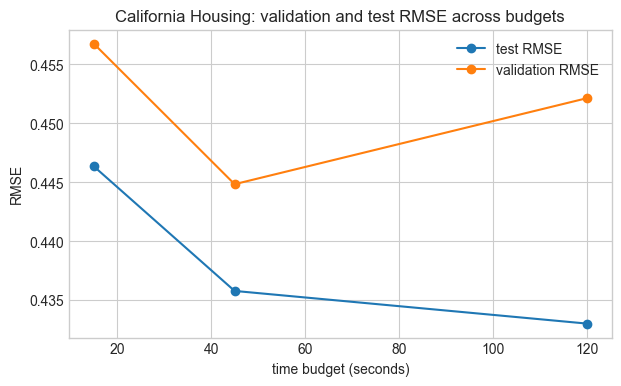

In [64]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(regression_budget_results["budget"], regression_budget_results["rmse"], marker="o", label="test RMSE")
ax.plot(regression_budget_results["budget"], regression_budget_results["best_loss"], marker="o", label="validation RMSE")
ax.set_xlabel("time budget (seconds)")
ax.set_ylabel("RMSE")
ax.set_title("California Housing: validation and test RMSE across budgets")
ax.legend()
plt.show()

## Combining Search Ideas

The Hutter and Vanschoren tutorial presents combinations of Bayesian optimization and multi-fidelity methods as a way to get both good anytime behavior and strong final performance.

## Budget Is a Modeling Decision

A system that is excellent after two hours may not be the best choice for an interactive workflow that allows only two minutes.

When reporting AutoML results, always state the time budget together with the chosen metric and selected model.

## 10. Model Inspection

For each FLAML run, record the choices needed to understand what was searched and why the result is reproducible.

## Reproducibility Checklist

- dataset name and version;
- feature preprocessing and missing-value handling;
- train/test split and random seed;
- task type and optimized metric;
- time budget;
- selected learner;
- best validation loss;
- best configuration;
- final test-set metrics.

AutoML is most useful when its choices are inspectable and reproducible.

In [65]:
summary = pd.DataFrame(
    [
        {
            "task": "classification",
            "dataset": adult_source,
            "optimized_metric": "roc_auc",
            "best_estimator": classification_automl.best_estimator,
            "best_loss": classification_automl.best_loss,
            **classification_automl_scores,
        },
        {
            "task": "regression",
            "dataset": housing_source,
            "optimized_metric": "rmse",
            "best_estimator": regression_automl.best_estimator,
            "best_loss": regression_automl.best_loss,
            **regression_automl_scores,
        },
    ]
)
summary.round(3)

,task,dataset,optimized_metric,best_estimator,best_loss,accuracy,roc_auc,f1,rmse,mae,r2
0,classification,OpenML Adult Census Income,roc_auc,xgboost,0.084,0.858,0.91,0.671,NaN,NaN,NaN
1,regression,California Housing,rmse,lgbm,0.776,NaN,NaN,NaN,0.637,0.47,0.693


## What AutoML Automates

AutoML can automate repetitive parts of modeling:

- trying candidate learners;
- allocating trials;
- tuning hyperparameters;
- returning a strong baseline.

## What AutoML Does Not Automate

AutoML does not remove the data-science responsibility for:

- problem formulation;
- target definition;
- leakage checks;
- fairness assessment;
- deployment monitoring;
- deciding whether a model should be used at all.

A good AutoML report explains both the machine-selected model and the human choices that shaped the search.

## Final Exercise: AutoML Audit Memo

Write a one-page audit memo for one FLAML model from this notebook.

Your memo should help a reader decide whether the model is a useful baseline, a deployable model, or only an exploratory result.

## Audit Memo Prompts

Answer these questions:

1. What exact task, metric, and time budget did FLAML optimize?
2. Which model did FLAML select, and how did it compare with the manual baseline?
3. What evidence suggests the result is reliable?
4. What evidence is still missing before deployment?
5. Which human modeling choice had the largest effect on the conclusion?

## Deliverables

Submit a short lab report with the core experimental results and your interpretation.

## Report Checklist

1. A one-paragraph summary of AutoML based on `hutter-vanschoren-part1-2.pdf`.
2. The manual and FLAML results for Adult Census Income.
3. The manual and FLAML results for California Housing.
4. The metric-choice comparison for classification.
5. The budget comparison for regression.
6. A short answer to: **What did AutoML automate here, and what did it not automate?**

## Extension Tasks

Choose one if you finish early:

- Add `estimator_list=["lgbm", "xgboost", "rf", "extra_tree"]` after installing the optional learners.
- Save and reload an AutoML run with `automl.pickle()` and `AutoML.load_pickle()`.
- Repeat the classification task with a fairness-sensitive subgroup comparison.

## More Extension Tasks

- Create a custom metric that penalizes false negatives more heavily than false positives.
- Compare FLAML with a manual `RandomizedSearchCV` baseline.
- Repeat the regression budget experiment with MAE instead of RMSE.
- Summarize how the selected learner changes as the budget increases.

## References

- Hutter, F., and Vanschoren, J. *Automatic Machine Learning (AutoML): A Tutorial*, NeurIPS 2018, Parts 1-2.
- Hutter, F., Kotthoff, L., and Vanschoren, J. (eds.). *Automated Machine Learning: Methods, Systems, Challenges*. Springer, 2019.
- FLAML documentation: Task-Oriented AutoML.
- FLAML documentation: AutoML Classification and Regression examples.
- OpenML Adult Census Income dataset.
- scikit-learn California Housing dataset.